In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
BASE_PATH = Path(r"C:\Users\Pocah\OneDrive\Desktop\bootcamp\python\Prepared Data")
INPUT_FILE = BASE_PATH / "instacart_plus_customers.pkl"
OUTPUT_FILE = BASE_PATH / "instacart_profiles_final.pkl"

In [4]:
# Load data
df = pd.read_pickle(INPUT_FILE)
print("Original shape:", df.shape)

Original shape: (32436241, 24)


#Exclude low-activity customers

In [5]:
order_counts = df.groupby("user_id")["order_number"].max()
df["total_orders"] = df["user_id"].map(order_counts)

In [6]:
print("Customers before filter:", df["user_id"].nunique())

Customers before filter: 206209


In [7]:
df_active = df[df["total_orders"] >= 5].copy()
print("Customers after filter:", df_active["user_id"].nunique())

Customers after filter: 162633


#Create customer profiles

In [8]:
# Convert safely
df_active["income"] = pd.to_numeric(df_active["income"], errors="coerce")
df_active["age"] = pd.to_numeric(df_active["age"], errors="coerce")
df_active["n_dependants"] = pd.to_numeric(df_active["n_dependants"], errors="coerce")

In [9]:
# Age bands
df_active["age_band"] = pd.cut(df_active["age"], bins=[0,29,49,64,120],
                               labels=["<30","30-49","50-64","65+"])

In [10]:
# Income bands (Low/Mid/High)
df_active["income_band"] = pd.qcut(df_active["income"], q=3,
                                   labels=["Low","Mid","High"], duplicates="drop")

In [11]:
# Dependants
df_active["dep_band"] = pd.cut(df_active["n_dependants"], bins=[-1,0,2,10],
                               labels=["0","1-2","3+"])

In [12]:
# Profile logic
def assign_profile(row):
    if row["income_band"]=="Low" and row["dep_band"]!="0":
        return "Budget Families"
    if row["income_band"]=="Low" and row["dep_band"]=="0":
        return "Budget Singles"
    if row["income_band"]=="High" and row["dep_band"]=="3+":
        return "Affluent Families"
    if row["income_band"]=="High":
        return "Affluent Professionals"
    return "Mid-range Households"

In [13]:
# Start with default profile
df_active["profile"] = "Mid-range Households"

# Budget Families
df_active.loc[(df_active["income_band"]=="Low") & (df_active["dep_band"]!="0"), "profile"] = "Budget Families"

# Budget Singles
df_active.loc[(df_active["income_band"]=="Low") & (df_active["dep_band"]=="0"), "profile"] = "Budget Singles"

# Affluent Families
df_active.loc[(df_active["income_band"]=="High") & (df_active["dep_band"]=="3+"), "profile"] = "Affluent Families"

# Affluent Professionals
df_active.loc[(df_active["income_band"]=="High") & (df_active["dep_band"]!="3+"), "profile"] = "Affluent Professionals"

print(df_active["profile"].value_counts())


profile
Mid-range Households      10331703
Budget Families            7756835
Affluent Professionals     7723984
Affluent Families          2607330
Budget Singles             2574759
Name: count, dtype: int64


#Profile Distribution (Bar Chart)

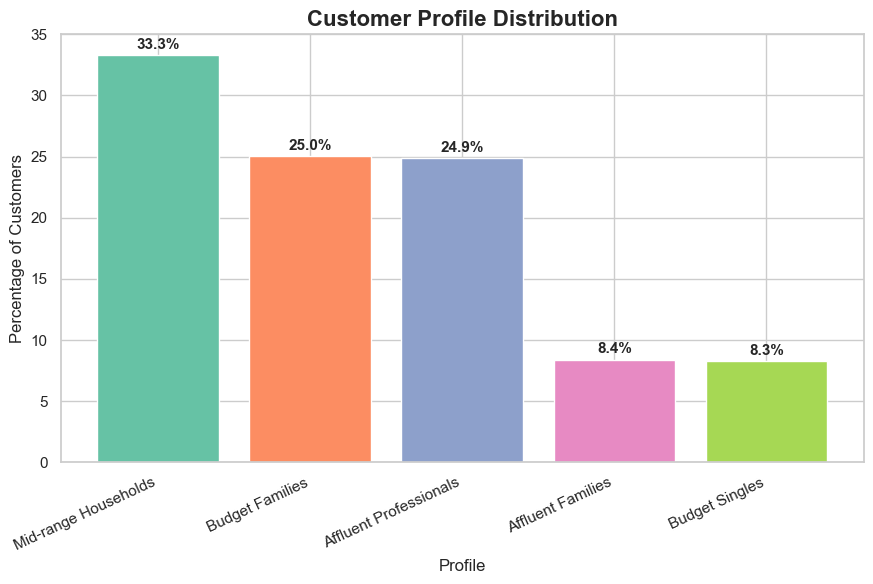

In [14]:
profile_counts = df_active["profile"].value_counts(normalize=True) * 100
profile_counts = profile_counts.sort_values(ascending=False)

# Pick colors manually (avoids warning)
colors = sns.color_palette("Set2", n_colors=len(profile_counts))

plt.figure(figsize=(9,6))
bars = plt.bar(profile_counts.index, profile_counts.values, color=colors)

# Add labels
for bar, v in zip(bars, profile_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.5, f"{v:.1f}%",
             ha="center", fontsize=11, fontweight="bold")

plt.title("Customer Profile Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Profile", fontsize=12)
plt.ylabel("Percentage of Customers", fontsize=12)
plt.xticks(rotation=25, ha="right", fontsize=11)
plt.tight_layout()

#Save before showing
plt.savefig("profile_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


#Based on the dataset, Mid-range Households are the largest segment (33%), followed by Budget Families (25%) and Affluent Professionals (25%). Affluent Families and Budget Singles each make up ~8%. These proportions reflect the customer profiling logic applied to the project dataset

In [15]:
#checking columns 
print(df_active.columns.tolist())

['order_id', 'user_id', 'eval_set', 'order_number', 'order_day_of_week', 'order_hour_of_day', 'days_since_prior_order', 'product_id', 'add_to_cart_order', 'reordered', 'product_name', 'aisle_id', 'department_id', 'prices', '_merge', 'first_name', 'surnam', 'gender', 'state', 'age', 'date_joined', 'n_dependants', 'fam_status', 'income', 'total_orders', 'age_band', 'income_band', 'dep_band', 'profile']


In [16]:
state_to_region = {
    # West
    "CA":"West", "WA":"West", "OR":"West", "NV":"West", "AZ":"West", "CO":"West",
    # Northeast
    "NY":"Northeast", "NJ":"Northeast", "MA":"Northeast", "PA":"Northeast", "CT":"Northeast",
    # South
    "TX":"South", "FL":"South", "GA":"South", "NC":"South", "VA":"South", "MD":"South",
    # Midwest
    "IL":"Midwest", "OH":"Midwest", "MI":"Midwest", "WI":"Midwest", "MN":"Midwest", "MO":"Midwest"
}

# Create region column from state
df_active["region"] = df_active["state"].map(state_to_region).fillna("Other")

print(df_active[["state","region"]].head())


     state region
0  Alabama  Other
1  Alabama  Other
2  Alabama  Other
3  Alabama  Other
4  Alabama  Other


In [17]:
#fixing_state_names 
#Full state name to region mapping
state_to_region = {
    # Northeast
    "Maine":"Northeast","New Hampshire":"Northeast","Vermont":"Northeast","Massachusetts":"Northeast",
    "Rhode Island":"Northeast","Connecticut":"Northeast","New York":"Northeast","New Jersey":"Northeast","Pennsylvania":"Northeast",

    # Midwest
    "Ohio":"Midwest","Indiana":"Midwest","Illinois":"Midwest","Michigan":"Midwest","Wisconsin":"Midwest",
    "Minnesota":"Midwest","Iowa":"Midwest","Missouri":"Midwest","North Dakota":"Midwest","South Dakota":"Midwest",
    "Nebraska":"Midwest","Kansas":"Midwest",

    # South
    "Delaware":"South","Maryland":"South","Virginia":"South","West Virginia":"South","Kentucky":"South",
    "North Carolina":"South","South Carolina":"South","Tennessee":"South","Georgia":"South","Florida":"South",
    "Alabama":"South","Mississippi":"South","Arkansas":"South","Louisiana":"South","Texas":"South","Oklahoma":"South",

    # West
    "Montana":"West","Idaho":"West","Wyoming":"West","Colorado":"West","New Mexico":"West",
    "Arizona":"West","Utah":"West","Nevada":"West","California":"West","Oregon":"West","Washington":"West","Alaska":"West","Hawaii":"West"
}

# Apply mapping
df_active["region"] = df_active["state"].map(state_to_region).fillna("Other")

print(df_active[["state","region"]].head(20))


      state region
0   Alabama  South
1   Alabama  South
2   Alabama  South
3   Alabama  South
4   Alabama  South
5   Alabama  South
6   Alabama  South
7   Alabama  South
8   Alabama  South
9   Alabama  South
10  Alabama  South
11  Alabama  South
12  Alabama  South
13  Alabama  South
14  Alabama  South
15  Alabama  South
16  Alabama  South
17  Alabama  South
18  Alabama  South
19  Alabama  South


#Profiles by Region

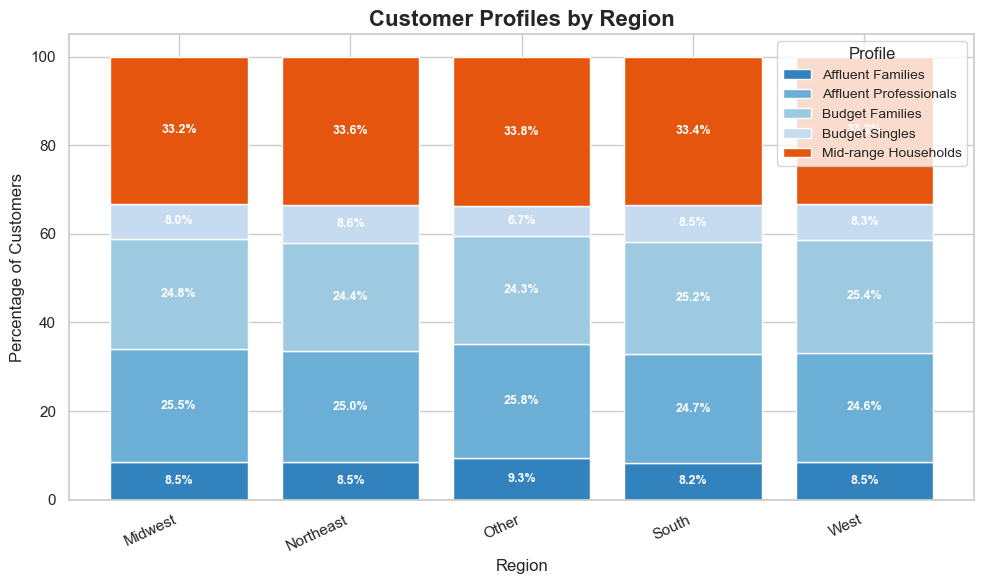

In [18]:
region_ct = pd.crosstab(df_active["region"], df_active["profile"], normalize="index") * 100

colors = sns.color_palette("tab20c", n_colors=region_ct.shape[1])

fig, ax = plt.subplots(figsize=(10,6))
bottom_vals = np.zeros(len(region_ct))

for i, col in enumerate(region_ct.columns):
    ax.bar(region_ct.index, region_ct[col], bottom=bottom_vals,
           label=col, color=colors[i])
    bottom_vals += region_ct[col].values

# Add labels inside stacked bars
for i, region in enumerate(region_ct.index):
    cumulative = 0
    for j, col in enumerate(region_ct.columns):
        value = region_ct.iloc[i, j]
        if value > 5:  # only label if >5% for readability
            ax.text(i, cumulative + value/2, f"{value:.1f}%",
                    ha="center", va="center", fontsize=9, color="white", fontweight="bold")
        cumulative += value

ax.set_title("Customer Profiles by Region", fontsize=16, fontweight="bold")
ax.set_xlabel("Region", fontsize=12)
ax.set_ylabel("Percentage of Customers", fontsize=12)
plt.xticks(rotation=25, ha="right", fontsize=11)
plt.legend(title="Profile", fontsize=10)
plt.tight_layout()
#Save high-quality image
plt.savefig("profiles_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

#Across all regions, Mid-range Households remain the largest segment (~33%), with Budget Families and Affluent Professionals each at ~25%. Regional variation is minimal, suggesting a similar profile distribution nationwide within the dataset.
Note: These figures are dataset-specific, not nationally representative.

In [19]:
#mapping from the CF Instacart dataset
dept_map = {
    1: "Frozen",
    2: "Other",
    3: "Bakery",
    4: "Produce",
    5: "Alcohol",
    6: "International",
    7: "Beverages",
    8: "Pets",
    9: "Dry Goods Pasta",
    10: "Bulk",
    11: "Personal Care",
    12: "Meat Seafood",
    13: "Pantry",
    14: "Breakfast",
    15: "Canned Goods",
    16: "Dairy Eggs",
    17: "Household",
    18: "Snacks",
    19: "Deli",
    20: "Missing"
}

# Add a readable department name column
df_active["department"] = df_active["department_id"].map(dept_map)

#Heatmap with Department Names

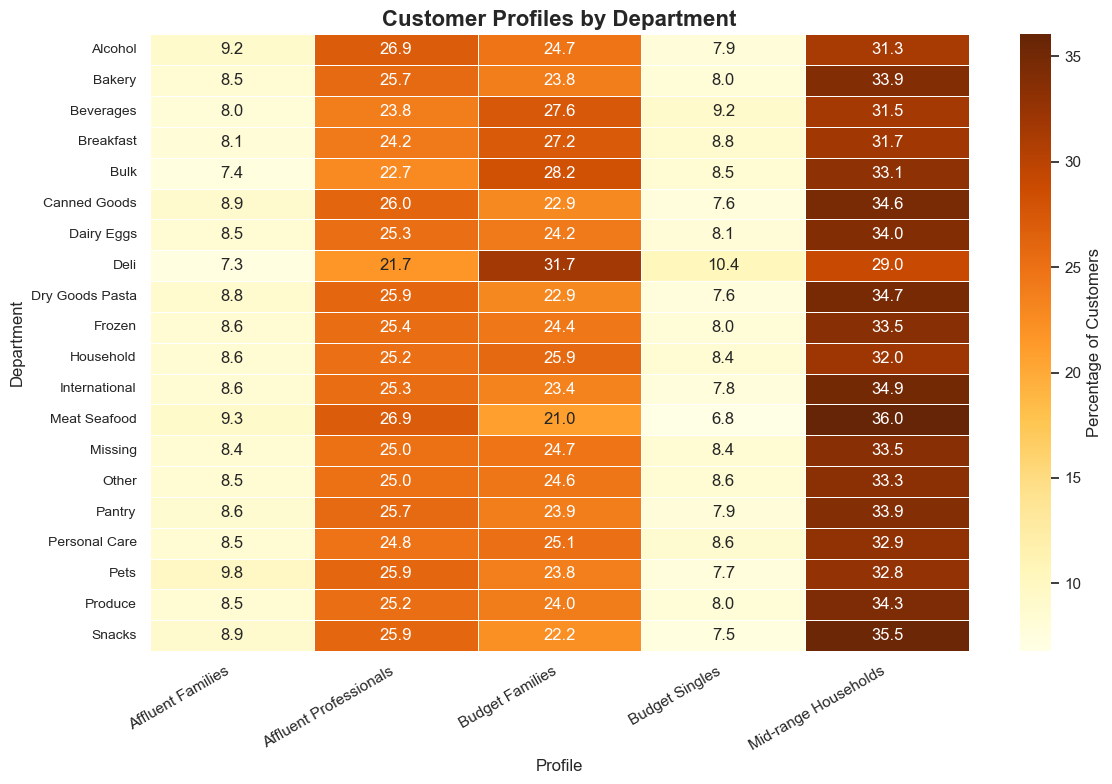

In [20]:
# Crosstab: Department × Profile (% within department)
dept_ct = pd.crosstab(df_active["department"], df_active["profile"], normalize="index") * 100

plt.figure(figsize=(12,8))
sns.heatmap(
    dept_ct, cmap="YlOrBr", annot=True, fmt=".1f", linewidths=.5,
    cbar_kws={"label": "Percentage of Customers"}
)

plt.title("Customer Profiles by Department", fontsize=16, fontweight="bold")
plt.xlabel("Profile", fontsize=12)
plt.ylabel("Department", fontsize=12)
plt.xticks(rotation=30, ha="right", fontsize=11)
plt.yticks(fontsize=10)
plt.tight_layout()
#Save a high-quality image
plt.savefig("profiles_by_department.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
import os

# Define export folder
export_folder = r"C:\Users\Pocah\OneDrive\Desktop\bootcamp\Sent to Clients"

# Create folder if it doesn't exist
os.makedirs(export_folder, exist_ok=True)

# Save DataFrame as Pickle
pkl_path = os.path.join(export_folder, "customer_profiles_clean.pkl")
df_active.to_pickle(pkl_path)

print("✅ Dataframe saved as:", pkl_path)


✅ Dataframe saved as: C:\Users\Pocah\OneDrive\Desktop\bootcamp\Sent to Clients\customer_profiles_clean.pkl
